# Hands-On AI for Science
## August 13, Morning: Learning and Generalization

Last session, we drove a loss function down to 0.004: a cubic polynomial, fit to 2000 samples of $\sin(x)$.  This hour starts with a question about that number.

**Was the model good?**  0.004 sounds good.  But good at *what*?

If you remember exactly one idea from this session, make it this: *how well a model fits the data you have* and *how well it will handle data you haven't seen* are *different quantities*.  You can make the first one arbitrarily small while the second one gets **worse**.  This lesson is about measuring the difference. And it's about the ways that measurement can go wrong in exactly the kinds of data that scientists have.

## Setup

Before anything else, the cell below checks that this notebook has what it needs: the required packages, and the data/homework files that ship with the workshop repository.  **If anything prints MISSING, fix it now, before going further.**

* A MISSING *package* under Anaconda usually means Anaconda isn't the Python running this notebook — ask an instructor.
* A MISSING *file* usually means Jupyter was started in the wrong folder.  Everything in this workshop assumes the notebook is opened from the repository's `lectures` folder (see the first notebook, `a12am_python.ipynb`, for how the repository is downloaded).
* After installing anything, always **restart the kernel** (Kernel → Restart Kernel) and re-run from the top.

In [ ]:
import importlib.util, os

packages = ['numpy', 'matplotlib', 'sklearn']
files = ['a13am_hw2.py']

for pkg in packages:
    print(f'{pkg:30s}', 'OK' if importlib.util.find_spec(pkg) is not None else 'MISSING')
for f in files:
    print(f'{f:30s}', 'OK' if os.path.exists(f) else 'MISSING')


1. [Model fit, revisited](#callback)
1. [Twelve noisy points](#twelve)
1. [Training error vs. test error](#ucurve)
1. [Two different questions](#twoquestions)
1. [Splitting honestly](#splitting)
1. [The traps in biological data](#groups)
1. [Leakage](#leakage)
1. [Five questions to ask about any accuracy](#checklist)
1. [Homework](#homework)

<a id="callback"></a>

## 1. Model fit, revisited

Two quick pieces of setup.  First, this morning's fit took 40,000 iterations of gradient descent.  For polynomials there is a shortcut: least squares (`np.linalg.lstsq`) jumps straight to the bottom of the error surface. Rebuilding this shortcut is your first homework function. Gradient descent still matters. For real neural networks there is no shortcut.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def fit_poly(x, y, degree):
    H = np.stack([x**k for k in range(degree + 1)], axis=1)   # columns: 1, x, x^2, ...
    coefs = np.linalg.lstsq(H, y, rcond=None)[0]
    return coefs

def poly_predict(coefs, x):
    return sum(c * x**k for k, c in enumerate(coefs))

x = np.linspace(-np.pi, np.pi, 2000)
y = np.sin(x)

coefs = fit_poly(x, y, 3)
mse = np.mean((poly_predict(coefs, x) - y)**2)
print('cubic fit to 2000 points:  MSE =', round(mse, 4))

cubic fit to 2000 points:  MSE = 0.0044


The same 0.004 as this morning.  Second piece of setup: notice what that number is.  It is the error **on the same 2000 points we used to fit the model**.  Keep that in mind.

<a id="twelve"></a>

## 2. Twenty-four noisy points

The previous lecture's setup had two luxuries we typically don't have in scientific research: 2000 samples, and zero noise.  In the real world, we often have to deal with **small sample sizes, with noise.**  The data might be generated from the same underlying truth ($\sin(x)$, dashed), but now it's hidden:

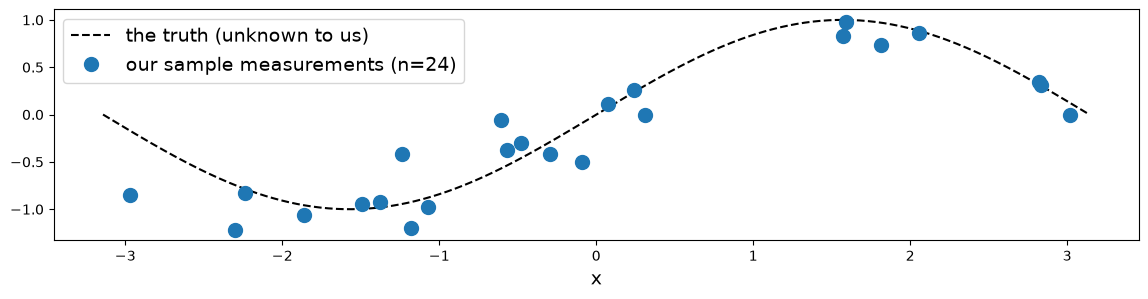

In [10]:
rng = np.random.default_rng(1)

training_sample_size = 24
x_train = np.sort(rng.uniform(-np.pi, np.pi, training_sample_size))
y_train = np.sin(x_train) + rng.normal(0, 0.25, training_sample_size)

xgrid = np.linspace(-np.pi, np.pi, 500)
fig = plt.figure(figsize=(14, 3))
ax = fig.subplots(1)
ax.plot(xgrid, np.sin(xgrid), 'k--', label='the truth (unknown to us)')
ax.plot(x_train, y_train, 'o', markersize=10, label=f'our sample measurements (n={training_sample_size})')
ax.legend(fontsize=14); ax.set_xlabel('x', fontsize=14);

Now let's fit polynomials of four different degrees — that is, four models of increasing **flexibility**.  Degree 1 is a straight line (2 knobs).  Degree 24 has 25 parameters — more parameters than we have data points.

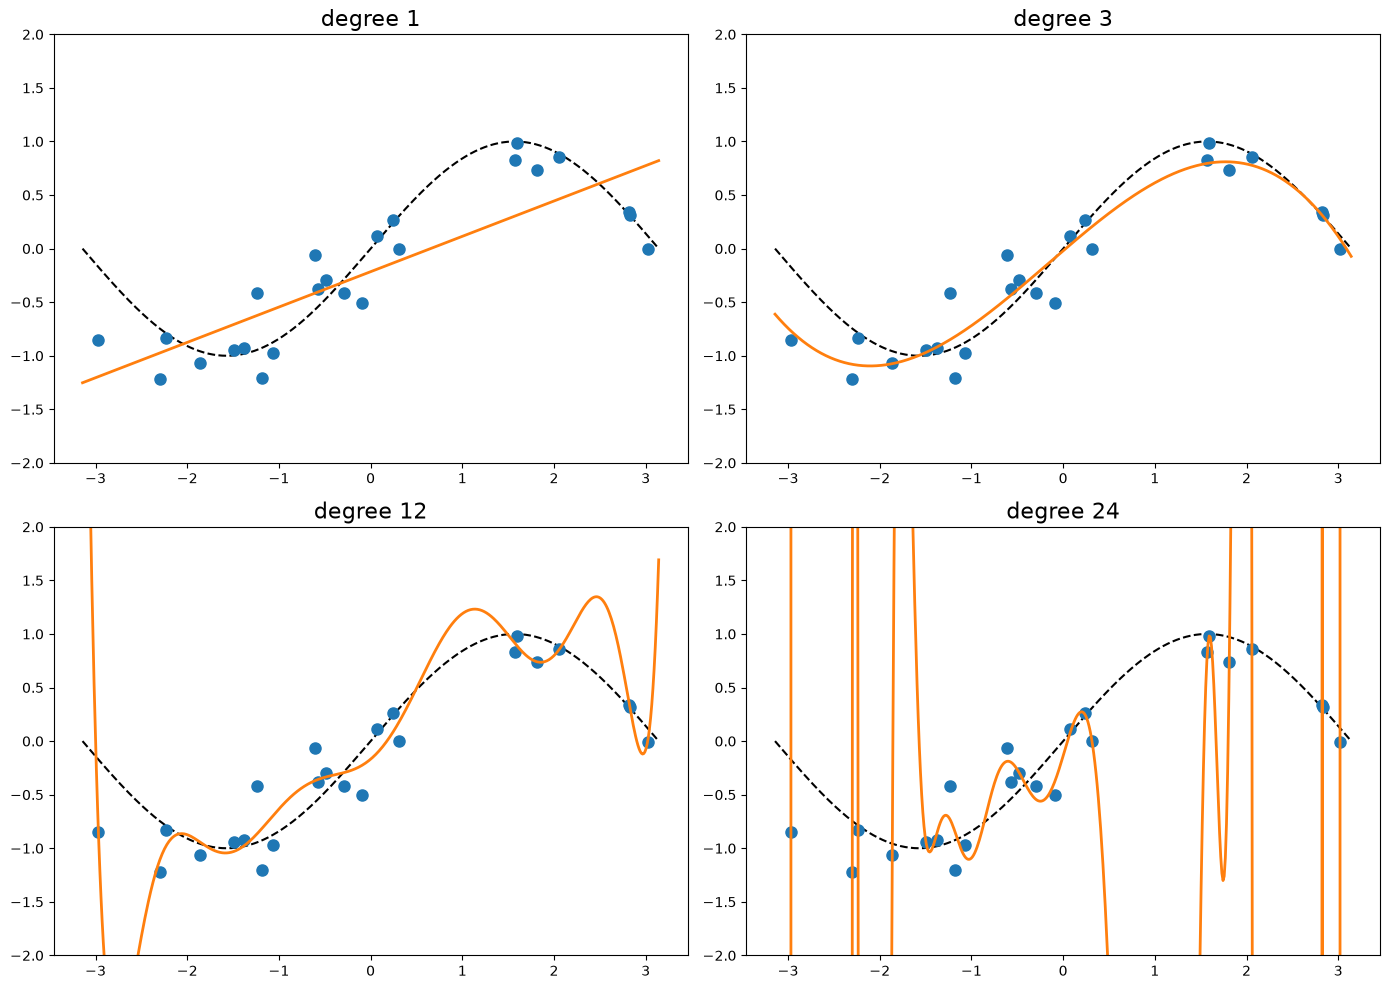

In [11]:
fig = plt.figure(figsize=(14, 10), layout='tight')
axs = fig.subplots(2, 2)
for ax, degree in zip(axs.flat, [1, 3, training_sample_size//2, training_sample_size]):
    coefs = fit_poly(x_train, y_train, degree)
    ax.plot(xgrid, np.sin(xgrid), 'k--')
    ax.plot(x_train, y_train, 'o', markersize=8)
    ax.plot(xgrid, poly_predict(coefs, xgrid), '-', linewidth=2)
    ax.set_ylim(-2, 2)
    ax.set_title(f'degree {degree}', fontsize=16)

Look at our largest model. The curve passes through (nearly) **every data point**. Its error on our sample measurements is essentially zero — while being wildly wrong everywhere in between.  A model with as many parameters as data points doesn't have to learn the pattern; it can simply *memorize the points*, noise and all.

My eye says degree 3 is the best of the four.  Let's turn that intuition into a number.

<a id="ucurve"></a>

## 3. Training error vs. test error

Because this is a simulation, we can create **fresh data from the same generative function**. We can create new noisy measurements the models have never seen.  Error on the initial points we fit is called **training error**.  Error on the fresh points is called **test error** — it measures what we actually care about: performance on data the model didn't see.

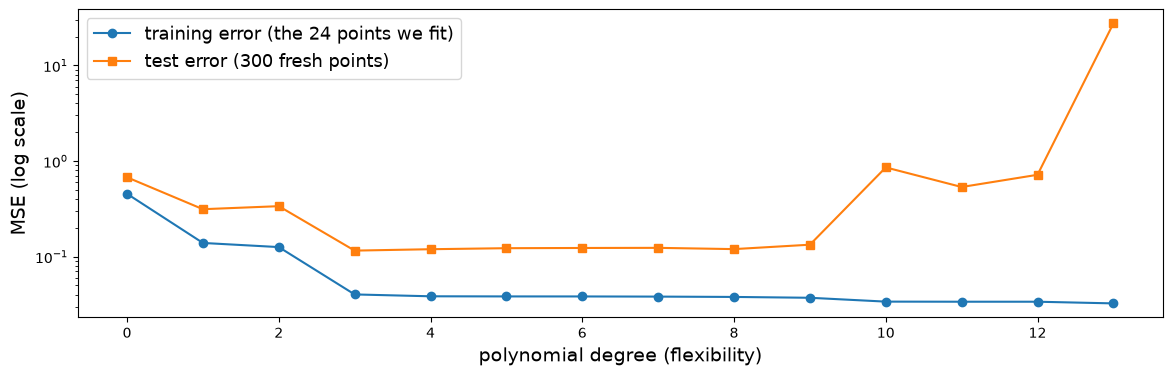

In [15]:
test_sample_size = 300
x_test = np.sort(rng.uniform(-np.pi, np.pi, test_sample_size))
y_test = np.sin(x_test) + rng.normal(0, 0.25, test_sample_size)

degrees = np.arange(0, 25)
train_err, test_err = [], []
for degree in degrees:
    coefs = fit_poly(x_train, y_train, degree)
    train_err.append(np.mean((poly_predict(coefs, x_train) - y_train)**2))
    test_err.append(np.mean((poly_predict(coefs, x_test) - y_test)**2))

fig = plt.figure(figsize=(14, 4))
ax = fig.subplots(1)
ax.semilogy(degrees, train_err, 'o-', label=f'training error (the {training_sample_size} points we fit)')
ax.semilogy(degrees, test_err, 's-', label=f'test error ({test_sample_size} fresh points)')
ax.set_xlabel('polynomial degree (flexibility)', fontsize=14)
ax.set_ylabel('MSE (log scale)', fontsize=14)
ax.legend(fontsize=13);

**This is one of the most important figures of the workshop.**  Two curves, two completely different stories:

* **Training error falls forever.**  More flexibility (more parameters) always helps you better fit the training data you already have. If you judge models by training error, the most complicated model always wins. This is a property of arithmetic, not evidence of quality.
* **Test error is U-shaped.**  Too little flexibility and the model can't capture the pattern (*underfitting*, left side).  Too much and it memorizes noise (*overfitting*, right side. Note the log scale: by degree 20 the test error isn't 2× worse, it's a *billion* times worse). Somewhere in between is a sweet spot. For our (imaginary) data, around degree 3 to 5. This is comforting, because the truth, y = sin(x), is well-approximated by a cubic function.

The 0.004 from this morning was a *training* error.  It answers "did the optimization work?"  It cannot answer "is the model any good?". For that, you need data the model never touched.

<a id="twoquestions"></a>

## 4. Two different questions: Inference vs. Prediction

This distinction deserves two minutes of philosophy of science, because it maps onto a fault line running through many scientific fields.

**Question 1 — inference:** *Is there a real relationship in my data?*  This is the world of p-values, effect sizes, confidence intervals, "treatment explains 40% of the variance."  The entire calculation happens **in-sample** — on the data you collected — and its validity rests on the assumptions of your statistical model.

**Question 2 — prediction:** *Will the model be right about the next case?*  The only convincing evidence is performance on data the model never saw.  No amount of in-sample fit substitutes.  As the figure above just showed, in-sample fit can be made perfect by memorization.

Neither question is better.  "This gene is associated with the disease ($p < 10^{-8}$)" and "this model diagnoses new patients at 90% accuracy" are both legitimate scientific claims. But they are **different claims**, supported by **different evidence**. The most common failure mode in the applied-ML literature of the last decade has been only answering Question 1 while claiming to have answered Question 2.  A model can explain 40% of variance in-sample and be useless on new patients, if the sample missed important aspects of variance present in the more general population.

*Further reading, both short and written for scientific audiences: Yarkoni T & Westfall J (2017), "Choosing prediction over explanation in psychology: lessons from machine learning," Perspectives on Psychological Science 12(6):1100–1122, [doi:10.1177/1745691617693393](https://doi.org/10.1177/1745691617693393); Bzdok D, Altman N & Krzywinski M (2018), "Statistics versus machine learning," Nature Methods 15:233–234, [doi:10.1038/nmeth.4642](https://doi.org/10.1038/nmeth.4642).*

<a id="splitting"></a>

## 5. Splitting honestly

In real life you usually can't conjure 300 fresh samples. So how can you protect yourself against overfitting, against choosing a model with too many parameters? A solution is to **hold back** part of the data you have, fit on the rest, and then treat the held-back part as your new sample.  That's the train/test split you saw in the scikit-learn demo.

But there's a subtlety.  Suppose you try ten model variants and pick the one with the best held-out error.  The held-out data has now *participated in a decision* — you shopped with it — and its error estimate is no longer an honest preview of the future.  Hence the standard three-way split:

* **training set** — fit the parameters;
* **validation set** — compare and choose between models (degrees, settings, features);
* **test set** — used only **once**, at the very end, to report the final prediction performance.

When data is too scarce to carve up three ways, an option is to use **k-fold cross-validation** on the non-test portion. This means splitting your data into k parts, hold out each part in turn, and then average the results.  Every point gets used for both fitting and validating, but never in the same round.

In [16]:
from sklearn.model_selection import KFold

rng2 = np.random.default_rng(2)
x40 = np.sort(rng2.uniform(-np.pi, np.pi, 40))
y40 = np.sin(x40) + rng2.normal(0, 0.25, 40)

kf = KFold(n_splits=5, shuffle=True, random_state=0)
for degree in [1, 3, 5, 9, 12]:
    fold_err = []
    for train_idx, val_idx in kf.split(x40):
        coefs = fit_poly(x40[train_idx], y40[train_idx], degree)
        fold_err.append(np.mean((poly_predict(coefs, x40[val_idx]) - y40[val_idx])**2))
    print(f'degree {degree:2d}:  5-fold cross-validation MSE = {np.mean(fold_err):.3f}')

degree  1:  5-fold cross-validation MSE = 0.205
degree  3:  5-fold cross-validation MSE = 0.082
degree  5:  5-fold cross-validation MSE = 0.084
degree  9:  5-fold cross-validation MSE = 0.782
degree 12:  5-fold cross-validation MSE = 2.535


Cross-validation picks a small-middle degree — the same verdict as the U-curve, but computed without any magical fresh data.  (For scikit-learn models, `cross_val_score` does this loop in one line; we wrote it out so you can see there's no magic in it.)

<a id="groups"></a>

## 6. Common traps in data

Everything above assumed our samples are **independent**. In other words, that a random split puts genuinely *new* data on the test side.   Data from many sciences, especially biology and psychology, routinely violates this:

* **Repeated measures** — five tissue samples from the same animal; trials from the same subject.
* **Batches** — samples processed on the same plate, day, scanner, or sequencing run.
* **Related sequences** — homologous proteins, strains from the same lineage.

Split randomly, and near-copies of the same mouse/plate/protein land on *both* sides.  The model can then score well by **recognizing the individual**, not by learning the biology — and the test set can't catch it, because the individuals aren't new.

We can demonstrate this in a simulation using synthetic data, deliberately built like a real experiment. Say we have 20 mice, 15 samples each, 10 features.  Each mouse has its own baseline fingerprint (biological individuality), and a *weak* disease signal on top:

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_score

rng5 = np.random.default_rng(5)
n_mice, samples_per_mouse, n_features = 20, 15, 10
mouse_label = np.array([0]*10 + [1]*10)          # 10 healthy mice, 10 diseased

X_rows, y_rows, mouse_id = [], [], []            # three empty lists to store our data
for m in range(n_mice):
    fingerprint = rng5.normal(0, 2.0, n_features)          # this mouse's baseline
    for _ in range(samples_per_mouse):
        row = fingerprint + rng5.normal(0, 1.0, n_features)
        row[:3] += 0.6 * mouse_label[m]                     # weak disease signal
        X_rows.append(row); y_rows.append(mouse_label[m]); mouse_id.append(m)
X_mice, y_mice, mouse_id = np.array(X_rows), np.array(y_rows), np.array(mouse_id)

model = LogisticRegression(max_iter=1000)
acc_random  = cross_val_score(model, X_mice, y_mice, cv=KFold(5, shuffle=True, random_state=0)).mean()
acc_grouped = cross_val_score(model, X_mice, y_mice, cv=GroupKFold(5), groups=mouse_id).mean()

print(f'random split:              accuracy = {acc_random:.3f}')
print(f'split by mouse (grouped):  accuracy = {acc_grouped:.3f}')

random split:              accuracy = 0.783
split by mouse (grouped):  accuracy = 0.510


Same data, same model — the only change is *how we split*.  The random split reports ~78%.  The grouped split — where every mouse's samples stay together on one side — reports **chance**.

In other words, essentially *all* of the 78% was the model recognizing **which mouse it was looking at**, then recalling that mouse's label. But the honest question for a diagnostic is "does it work on a mouse it has never seen?". `GroupKFold` is the one-line way to ask it. This is why our previous dataset had a `mouse_id` column.  Whatever your version of *mouse* is — subject, plate, batch, protein family — if your data has repeated measurements of any kind, your data has this column. That means your splits need to respect it, or your model will be able to find a way to "cheat", and look like it's doing better at prediction than it really is.

<a id="leakage"></a>

## 7. Leakage

There is one more way an honest-looking split can deceive us. And this is an insidious one, because the split itself is fine.

**Leakage** is when any information from the test data influences any choice made during training.  The split above leaked *identity*.  But information can also leak through **preprocessing**. Any step that *learns numbers from the data* — selecting the "most informative" features, scaling, choosing imputation values — must learn them from the **training rows only**.  If you do any of these steps before the split, then the test rows have quietly contributed information on the model.

How bad can it be?  Let's find out, on data that is **pure noise**.  100 samples, 1000 random features, labels assigned by coin flip.  There is *nothing* to find.  Watch what "select the 20 best features, then split" produces:

In [19]:
from sklearn.model_selection import train_test_split

rng3 = np.random.default_rng(3)
X_noise = rng3.normal(size=(100, 1000))
y_noise = np.array([0, 1] * 50)          # coin-flip labels: no real signal exists

def top20(X, y):
    # Return the indices of the 20 features most correlated with the labels
    # (correlate each column of X with y, rank by |r|, keep the strongest 20).
    r = np.array([np.corrcoef(X[:, j], y)[0, 1] for j in range(X.shape[1])])
    return np.argsort(np.abs(r))[-20:]

# LEAKY: select features using ALL the data, then split
selected = top20(X_noise, y_noise)
Xtr, Xte, ytr, yte = train_test_split(X_noise[:, selected], y_noise, test_size=0.3, random_state=0)
leaky_acc = LogisticRegression(max_iter=1000).fit(Xtr, ytr).score(Xte, yte)

# HONEST: split first, select features using the training rows only
Xtr, Xte, ytr, yte = train_test_split(X_noise, y_noise, test_size=0.3, random_state=0)
selected = top20(Xtr, ytr)
honest_acc = LogisticRegression(max_iter=1000).fit(Xtr[:, selected], ytr).score(Xte[:, selected], yte)

print(f'leaky pipeline:   test accuracy = {leaky_acc:.2f}')
print(f'honest pipeline:  test accuracy = {honest_acc:.2f}')

leaky pipeline:   test accuracy = 0.90
honest pipeline:  test accuracy = 0.53


**90% accuracy on coin flips.**  With 1000 random features, a few *will* correlate with the labels by luck; selecting them before the split hands the test rows' luck to the model, and the "held-out" evaluation confirms a signal that does not exist.  The honest pipeline, on the same data, tells the truth: chance.

Nothing in the leaky pipeline looks exotic or like cheating.  "We screened features by t-test or correlation, then cross-validated a classifier". This is a sentence that has appeared in a great many published papers. But when the screening used all the data, it completely invalidates the value of a test set for making predictions about a novel sample.  Also in this family: scaling/normalizing with statistics computed on all the data (this is why yesterday's `StandardScaler` was fit on the training rows only), imputing from all the data, running PCA before splitting, and tuning hyperparameters against the test set.

<a id="checklist"></a>

## 8. Five questions to ask about any accuracy

Before believing any reported performance number — including your own:

1. **What would chance be?**  90% accuracy is meaningless until you know whether 50% or 89% of the samples share one class.
2. **Did the test data influence *any* decision?**  Features, scaling, imputation, model choice, hyperparameters, when to stop training.  Any yes → the number is inflated.
3. **Is the test data truly independent of the training data?**  Same subjects?  Same batch or plate?  Homologous sequences?  Overlapping time windows?
4. **How big is the test set?**  An accuracy from 30 test samples has error bars of roughly ±15 percentage points.  Most model-vs-model differences are smaller than that.
5. **Would it survive a new lab, batch, or cohort?**  Passing your own held-out data is the bare minimum.  Distribution shift across contexts is still a concern, one we will return to in a later lecture.

This list will return, expanded, in the final session of the workshop, as we apply these issues to more advanced forms of AI like large language models and image classifiers.

<a id="homework"></a>

## Homework

Four functions in `a13am_hw2.py`.  The first two we'll start here in session; the last two are yours to finish.  As before: open the file, delete the `raise RuntimeError` line, fill in your code, and use the check cells below.

The functions retrace this lecture: `fit_polynomial` (the lstsq shortcut), `train_test_error` (the split), `find_best_degree` (model selection done honestly), and `honest_vs_leaky` (reproduce Section 7's alarm on any dataset you like — including, after the workshop, your own).

In [ ]:
import a13am_hw2, importlib
importlib.reload(a13am_hw2)
help(a13am_hw2)

**Check `fit_polynomial`.**  Expected output:

```
degree-3 coefficients: [-0.02   0.732 -0.033 -0.065]
```
(Compare: the Taylor series says $\sin(x)\approx x - x^3/6 \approx (0,\ 1,\ 0,\ -0.167)$.  With 24 noisy points you get coefficients in the same family but not identical — that's noise doing its work.)

In [ ]:
importlib.reload(a13am_hw2)

coefs = a13am_hw2.fit_polynomial(x_train, y_train, 3)
print('degree-3 coefficients:', np.round(coefs, 3))

**Check `train_test_error`** on the 40-point dataset from Section 5.  Expected output:

```
degree  3:  train MSE = 0.0667   test MSE = 0.0800
degree 12:  train MSE = 0.0493   test MSE = 6.1297
```
Degree 12 *wins on training error* and loses by 75× on test error — the U-curve, reproduced by your own code.

In [ ]:
importlib.reload(a13am_hw2)

for degree in [3, 12]:
    tr, te = a13am_hw2.train_test_error(x40, y40, degree, split=0.7)
    print(f'degree {degree:2d}:  train MSE = {tr:.4f}   test MSE = {te:.4f}')

**Check `find_best_degree`.**  Expected output: `best degree: 5`

In [ ]:
importlib.reload(a13am_hw2)

print('best degree:', a13am_hw2.find_best_degree(x40, y40, [1, 3, 5, 9, 12]))

**Check `honest_vs_leaky`** on Section 7's pure-noise data.  Expected output:

```
honest: 0.53   leaky: 0.90
```

In [ ]:
importlib.reload(a13am_hw2)

honest, leaky = a13am_hw2.honest_vs_leaky(X_noise, y_noise)
print(f'honest: {honest:.2f}   leaky: {leaky:.2f}')

## Brief summary of this lecture

A flexible model can always fit your data. The only question that matters is whether it fits **the next** data. If and when a model overfits, your two honest options are *more data* or *a simpler model*, and your evaluation is only as honest as your split.

Tomorrow we will look at models with hundreds of millions of parameters — flexibility beyond anything in today's U-curve.  Everything about how those are used safely needs to follow from what we just learned.